Pre checks

In [1]:
import torch

assert torch.cuda.is_available(), "No GPU detected. Enable a GPU runtime."
gpu = torch.cuda.get_device_name(0)
memory_gb = torch.cuda.get_device_properties(0).total_memory / 2**30

print("GPU: ", gpu)
print(f"GPU memory: {memory_gb:.1f} GiB")
print("BF16 supported: ", torch.cuda.is_bf16_supported())

GPU:  Tesla T4
GPU memory: 14.6 GiB
BF16 supported:  True


Drive Mount

In [15]:
from google.colab import drive

drive.mount('/content/drive')
%cd "/content/drive/MyDrive/probing"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/probing


Verify

In [16]:
!ls -lh
!ls -lh dataset

total 73K
drwx------ 2 root root 4.0K Sep  7 14:41 dataset
-rw------- 1 root root  61K Sep  7 14:27 gemma7b_every_4th_layer_probe.py
drwx------ 2 root root 4.0K Sep  7 15:10 qwen35_4b_probe_results_4bit
drwx------ 2 root root 4.0K Sep  7 15:21 qwen35_4b_probe_results_unquantized
total 557K
-rw------- 1 root root 290K Sep  7 15:16 common_claim_true_false_2000.json
-rw------- 1 root root 268K Sep  7 14:23 json_merged.json


Dependency installation

In [ ]:
%pip install -U \
"transformers @ git+https://github.com/huggingface/transformers.git@main" \
accelerate \
bitsandbytes \
scikit-learn \
numpy \
joblib \
matplotlib \
tqdm \
huggingface_hub \
sentencepiece

Verify again

In [5]:
import torch
import transformers
import bitsandbytes

print("PyTorch: ", torch.__version__)
print("Transformers: ", transformers.__version__)
print("GPU: ", torch.cuda.get_device_name(0))

PyTorch:  2.11.0+cu128
Transformers:  5.17.0.dev0
GPU:  Tesla T4


Enable Colab Mode

In [6]:
%env PROBE_ALLOW_NON_CONDA=1

env: PROBE_ALLOW_NON_CONDA=1


**Probe for German Language**

Validate dataset

In [7]:
!python gemma7b_every_4th_layer_probe.py \
  --data dataset/json_merged.json \
  --validate-only

Dataset validation passed
  records: 2000
  labels: {'0': 1000, '1': 1000}
  tag × label: {'geography': {'0': 250, '1': 250}, 'sports': {'0': 250, '1': 250}, 'entertainment': {'0': 250, '1': 250}, 'history_news': {'0': 250, '1': 250}}
  rows consolidated into split groups: 254 (kept together)
  grouping: normalized exact text + verified uploaded-dataset sports pairs
  split caveat: The source file has no global fact/pair ID. Other near-counterfactual statements may cross splits, so this is group-aware IID evaluation, not a fully content-disjoint evaluation.
  train: 1200 rows, {'0': 600, '1': 600}
  validation: 400 rows, {'0': 200, '1': 200}
  test: 400 rows, {'0': 200, '1': 200}
Validation-only mode complete; the model was not loaded.


Run the probe \
Quantization: 4 bit \
Language: German

In [8]:
!python gemma7b_every_4th_layer_probe.py \
    --data dataset/json_merged.json \
    --model-id Qwen/Qwen3.5-4B \
    --output-dir qwen35_4b_probe_results_4bit \
    --layer-step 4 \
    --batch-size 2 \
    --max-length 128 \
    --pooling last \
    --dtype float16 \
    --quantization 4bit

Dataset validation passed
  records: 2000
  labels: {'0': 1000, '1': 1000}
  tag × label: {'geography': {'0': 250, '1': 250}, 'sports': {'0': 250, '1': 250}, 'entertainment': {'0': 250, '1': 250}, 'history_news': {'0': 250, '1': 250}}
  rows consolidated into split groups: 254 (kept together)
  grouping: normalized exact text + verified uploaded-dataset sports pairs
  split caveat: The source file has no global fact/pair ID. Other near-counterfactual statements may cross splits, so this is group-aware IID evaluation, not a fully content-disjoint evaluation.
  train: 1200 rows, {'0': 600, '1': 600}
  validation: 400 rows, {'0': 200, '1': 200}
  test: 400 rows, {'0': 200, '1': 200}












Loaded Qwen/Qwen3.5-4B: 32 blocks; probing [4, 8, 12, 16, 20, 24, 28, 32]; dtype=float16, quantization=4bit
Tokenization: {'min_tokens': 5, 'median_tokens': 13.0, 'p95_tokens': 22.0, 'max_tokens': 30, 'max_length': 128, 'n_truncated': 0, 'add_special_tokens': True, 'bos_token_id': None, 'eos_token_

Run the probe \
Quantization = None \
Language = German


In [13]:
!python gemma7b_every_4th_layer_probe.py \
    --data dataset/json_merged.json \
    --model-id Qwen/Qwen3.5-4B \
    --output-dir qwen35_4b_probe_results_unquantized \
    --layer-step 4 \
    --batch-size 2 \
    --max-length 128 \
    --pooling last \
    --dtype float16 \
    --quantization none

Dataset validation passed
  records: 2000
  labels: {'0': 1000, '1': 1000}
  tag × label: {'geography': {'0': 250, '1': 250}, 'sports': {'0': 250, '1': 250}, 'entertainment': {'0': 250, '1': 250}, 'history_news': {'0': 250, '1': 250}}
  rows consolidated into split groups: 254 (kept together)
  grouping: normalized exact text + verified uploaded-dataset sports pairs
  split caveat: The source file has no global fact/pair ID. Other near-counterfactual statements may cross splits, so this is group-aware IID evaluation, not a fully content-disjoint evaluation.
  train: 1200 rows, {'0': 600, '1': 600}
  validation: 400 rows, {'0': 200, '1': 200}
  test: 400 rows, {'0': 200, '1': 200}

Loaded Qwen/Qwen3.5-4B: 32 blocks; probing [4, 8, 12, 16, 20, 24, 28, 32]; dtype=float16, quantization=none
Tokenization: {'min_tokens': 5, 'median_tokens': 13.0, 'p95_tokens': 22.0, 'max_tokens': 30, 'max_length': 128, 'n_truncated': 0, 'add_special_tokens': True, 'bos_token_id': None, 'eos_token_id': 248046

**Probe for English Language**

Verify dataset

In [20]:
!python gemma7b_every_4th_layer_probe.py \
  --data dataset/common_claim_true_false_2000.json \
  --validate-only

Dataset validation passed
  records: 2000
  labels: {'0': 1000, '1': 1000}
  tag × label: {'common_claim': {'0': 1000, '1': 1000}}
  rows consolidated into split groups: 0 (kept together)
  grouping: normalized exact text only
  split caveat: Only exact duplicates are grouped; semantic/counterfactual counterparts may cross splits unless --group-field is supplied.
  train: 1200 rows, {'0': 600, '1': 600}
  validation: 400 rows, {'0': 200, '1': 200}
  test: 400 rows, {'0': 200, '1': 200}
Validation-only mode complete; the model was not loaded.


Run the probe \
Quantization = 4 bit \
Language = English

In [18]:
!python gemma7b_every_4th_layer_probe.py \
    --data dataset/common_claim_true_false_2000.json \
    --model-id Qwen/Qwen3.5-4B \
    --output-dir qwen35_4b_probe_results_english_4bit \
    --layer-step 4 \
    --batch-size 2 \
    --max-length 128 \
    --pooling last \
    --dtype float16 \
    --quantization 4bit

Dataset validation passed
  records: 2000
  labels: {'0': 1000, '1': 1000}
  tag × label: {'common_claim': {'0': 1000, '1': 1000}}
  rows consolidated into split groups: 0 (kept together)
  grouping: normalized exact text only
  split caveat: Only exact duplicates are grouped; semantic/counterfactual counterparts may cross splits unless --group-field is supplied.
  train: 1200 rows, {'0': 600, '1': 600}
  validation: 400 rows, {'0': 200, '1': 200}
  test: 400 rows, {'0': 200, '1': 200}

Loaded Qwen/Qwen3.5-4B: 32 blocks; probing [4, 8, 12, 16, 20, 24, 28, 32]; dtype=float16, quantization=4bit
Tokenization: {'min_tokens': 5, 'median_tokens': 13.0, 'p95_tokens': 19.0, 'max_tokens': 23, 'max_length': 128, 'n_truncated': 0, 'add_special_tokens': True, 'bos_token_id': None, 'eos_token_id': 248046, 'add_bos_token': False, 'add_eos_token': False}
[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct 

Run the probe \
Quantization = None \
Language = English

In [22]:
!python gemma7b_every_4th_layer_probe.py \
    --data dataset/common_claim_true_false_2000.json \
    --model-id Qwen/Qwen3.5-4B \
    --output-dir qwen35_4b_probe_results_english_unquantized \
    --layer-step 4 \
    --batch-size 2 \
    --max-length 128 \
    --pooling last \
    --dtype float16 \
    --quantization none

Dataset validation passed
  records: 2000
  labels: {'0': 1000, '1': 1000}
  tag × label: {'common_claim': {'0': 1000, '1': 1000}}
  rows consolidated into split groups: 0 (kept together)
  grouping: normalized exact text only
  split caveat: Only exact duplicates are grouped; semantic/counterfactual counterparts may cross splits unless --group-field is supplied.
  train: 1200 rows, {'0': 600, '1': 600}
  validation: 400 rows, {'0': 200, '1': 200}
  test: 400 rows, {'0': 200, '1': 200}

Loaded Qwen/Qwen3.5-4B: 32 blocks; probing [4, 8, 12, 16, 20, 24, 28, 32]; dtype=float16, quantization=none
Tokenization: {'min_tokens': 5, 'median_tokens': 13.0, 'p95_tokens': 19.0, 'max_tokens': 23, 'max_length': 128, 'n_truncated': 0, 'add_special_tokens': True, 'bos_token_id': None, 'eos_token_id': 248046, 'add_bos_token': False, 'add_eos_token': False}
[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct 

**Result Inspection**

Imports

In [23]:
import pandas as pd
from IPython.display import Image, display

Layer performance table

In [24]:
def show_layer_performance(result_dir):
  path = f"{result_dir}/metrics.csv"
  results = pd.read_csv(path)
  display(results)

In [26]:
from numpy._core.multiarray import packbits
from os import path
def show_plot(result_dir):
  path = f"{result_dir}/layerwise_metrics.png"
  display(Image(filename=path))

**Result: German 4 bit quantized**

*   List item
*   List item



In [28]:
show_layer_performance("qwen35_4b_probe_results_4bit")

,layer,selected_C,validation_n,validation_accuracy,validation_balanced_accuracy,validation_f1,validation_precision,validation_sensitivity,validation_specificity,validation_mcc,...,test_brier_score,test_log_loss,test_accuracy_ci_low,test_accuracy_ci_high,test_balanced_accuracy_ci_low,test_balanced_accuracy_ci_high,test_f1_ci_low,test_f1_ci_high,test_roc_auc_ci_low,test_roc_auc_ci_high
0,4,0.0001,400,0.5100,0.5100,0.533333,0.509091,0.560,0.460,0.020101,...,0.249468,0.692058,0.464822,0.557506,0.465960,0.557063,0.461936,0.572116,0.467470,0.573165
1,8,0.0010,400,0.5625,0.5625,0.570025,0.560386,0.580,0.545,0.125077,...,0.253100,0.701174,0.515227,0.611414,0.515493,0.612444,0.528390,0.632800,0.510944,0.621415
2,12,0.0010,400,0.6450,0.6450,0.660287,0.633028,0.690,0.600,0.291182,...,0.221976,0.629353,0.568165,0.663317,0.568204,0.663059,0.589391,0.687070,0.638652,0.741861
3,16,0.0001,400,0.7350,0.7350,0.777311,0.670290,0.925,0.545,0.508116,...,0.173134,0.519551,0.679293,0.768473,0.679967,0.764920,0.711397,0.795557,0.796678,0.869877
4,20,0.0010,400,0.7450,0.7450,0.768182,0.704167,0.845,0.645,0.500104,...,0.177157,0.521511,0.666625,0.754443,0.666089,0.754486,0.689977,0.775424,0.770233,0.852102
5,24,0.0010,400,0.7225,0.7225,0.752784,0.678715,0.845,0.600,0.458989,...,0.183421,0.539756,0.659088,0.745111,0.657952,0.744354,0.686495,0.769920,0.750720,0.838158
6,28,0.0010,400,0.6950,0.6950,0.722727,0.662500,0.795,0.595,0.398042,...,0.194547,0.568902,0.644496,0.731360,0.643864,0.729752,0.668353,0.757385,0.725085,0.814493
7,32,0.0010,400,0.6950,0.6950,0.726457,0.658537,0.810,0.580,0.400744,...,0.196046,0.573057,0.661798,0.752517,0.662288,0.751318,0.690580,0.777012,0.720471,0.810313


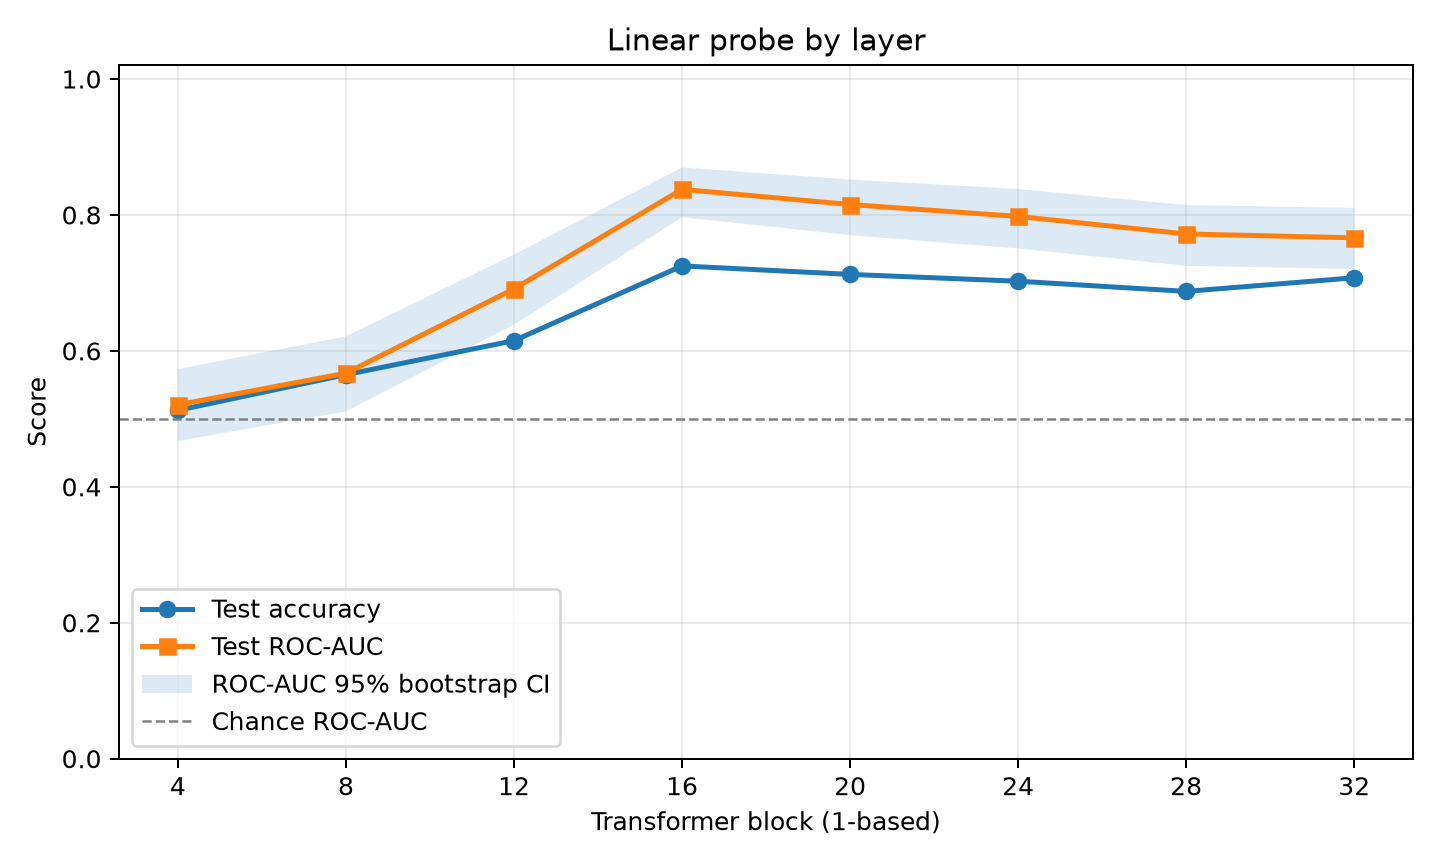

In [29]:
show_plot("qwen35_4b_probe_results_4bit")

**Result: German unquantized**

In [30]:
show_layer_performance("qwen35_4b_probe_results_unquantized")

,layer,selected_C,validation_n,validation_accuracy,validation_balanced_accuracy,validation_f1,validation_precision,validation_sensitivity,validation_specificity,validation_mcc,...,test_brier_score,test_log_loss,test_accuracy_ci_low,test_accuracy_ci_high,test_balanced_accuracy_ci_low,test_balanced_accuracy_ci_high,test_f1_ci_low,test_f1_ci_high,test_roc_auc_ci_low,test_roc_auc_ci_high
0,4,0.0010,400,0.5225,0.5225,0.523691,0.522388,0.525,0.520,0.045001,...,0.262044,0.719116,0.463816,0.558313,0.462763,0.558385,0.446126,0.561153,0.451778,0.558888
1,8,0.0010,400,0.5750,0.5750,0.579208,0.573529,0.585,0.565,0.150030,...,0.254083,0.704101,0.496221,0.591256,0.496602,0.591294,0.494817,0.604215,0.509813,0.620078
2,12,0.0010,400,0.6625,0.6625,0.679335,0.647059,0.715,0.610,0.326807,...,0.219644,0.624276,0.588821,0.683299,0.589644,0.684240,0.604753,0.703459,0.647682,0.751050
3,16,0.0001,400,0.7575,0.7575,0.795789,0.687273,0.945,0.570,0.555541,...,0.169447,0.509770,0.687813,0.775267,0.691346,0.772986,0.725165,0.805973,0.803022,0.876114
4,20,0.0010,400,0.7500,0.7500,0.772727,0.708333,0.850,0.650,0.510310,...,0.171334,0.501383,0.668341,0.758186,0.669325,0.757083,0.693748,0.779529,0.788343,0.865618
5,24,0.0010,400,0.7375,0.7375,0.767184,0.689243,0.865,0.610,0.491240,...,0.177775,0.521159,0.649734,0.738696,0.650107,0.737769,0.676185,0.763657,0.765433,0.846831
6,28,0.0010,400,0.7200,0.7200,0.750000,0.677419,0.840,0.600,0.453247,...,0.186536,0.544485,0.632754,0.723788,0.634366,0.721488,0.663494,0.750596,0.744478,0.827955
7,32,0.0010,400,0.7175,0.7175,0.743764,0.680498,0.820,0.615,0.444439,...,0.187895,0.548525,0.655854,0.745592,0.657352,0.743197,0.684725,0.769956,0.740155,0.826184


In [ ]:
show_plot("qwen35_4b_probe_results_unquantized")

**Result: English 4 bit quantized**

In [31]:
show_layer_performance("qwen35_4b_probe_results_english_4bit")

,layer,selected_C,validation_n,validation_accuracy,validation_balanced_accuracy,validation_f1,validation_precision,validation_sensitivity,validation_specificity,validation_mcc,...,test_brier_score,test_log_loss,test_accuracy_ci_low,test_accuracy_ci_high,test_balanced_accuracy_ci_low,test_balanced_accuracy_ci_high,test_f1_ci_low,test_f1_ci_high,test_roc_auc_ci_low,test_roc_auc_ci_high
0,4,0.001,400,0.7025,0.7025,0.703242,0.701493,0.705,0.700,0.405005,...,0.204155,0.595305,0.6225,0.712562,0.621283,0.714953,0.614173,0.720555,0.700208,0.795111
1,8,0.001,400,0.7025,0.7025,0.710462,0.691943,0.730,0.675,0.405614,...,0.187223,0.553145,0.6850,0.772562,0.684436,0.774694,0.672043,0.771144,0.741104,0.830203
2,12,0.001,400,0.7450,0.7450,0.747525,0.740196,0.755,0.735,0.490098,...,0.151940,0.463068,0.7275,0.810000,0.728884,0.810128,0.728562,0.813958,0.823761,0.893747
3,16,0.001,400,0.8000,0.8000,0.808612,0.775229,0.845,0.755,0.602445,...,0.120023,0.389489,0.7975,0.867563,0.798455,0.868875,0.800000,0.872650,0.876065,0.936802
4,20,0.001,400,0.8050,0.8050,0.808824,0.793269,0.825,0.785,0.610489,...,0.128276,0.409121,0.7650,0.842500,0.766336,0.844119,0.769967,0.849318,0.863724,0.926328
5,24,0.001,400,0.7950,0.7950,0.800000,0.780952,0.820,0.770,0.590739,...,0.138926,0.437538,0.7550,0.832500,0.755000,0.832366,0.758794,0.839332,0.845565,0.915141
6,28,0.001,400,0.7700,0.7700,0.777778,0.752336,0.805,0.735,0.541328,...,0.148561,0.459356,0.7450,0.825000,0.744987,0.823472,0.749326,0.832961,0.829230,0.900187
7,32,0.001,400,0.7800,0.7800,0.785366,0.766667,0.805,0.755,0.560701,...,0.155667,0.475356,0.7225,0.805000,0.722555,0.805141,0.726306,0.815149,0.818573,0.890527


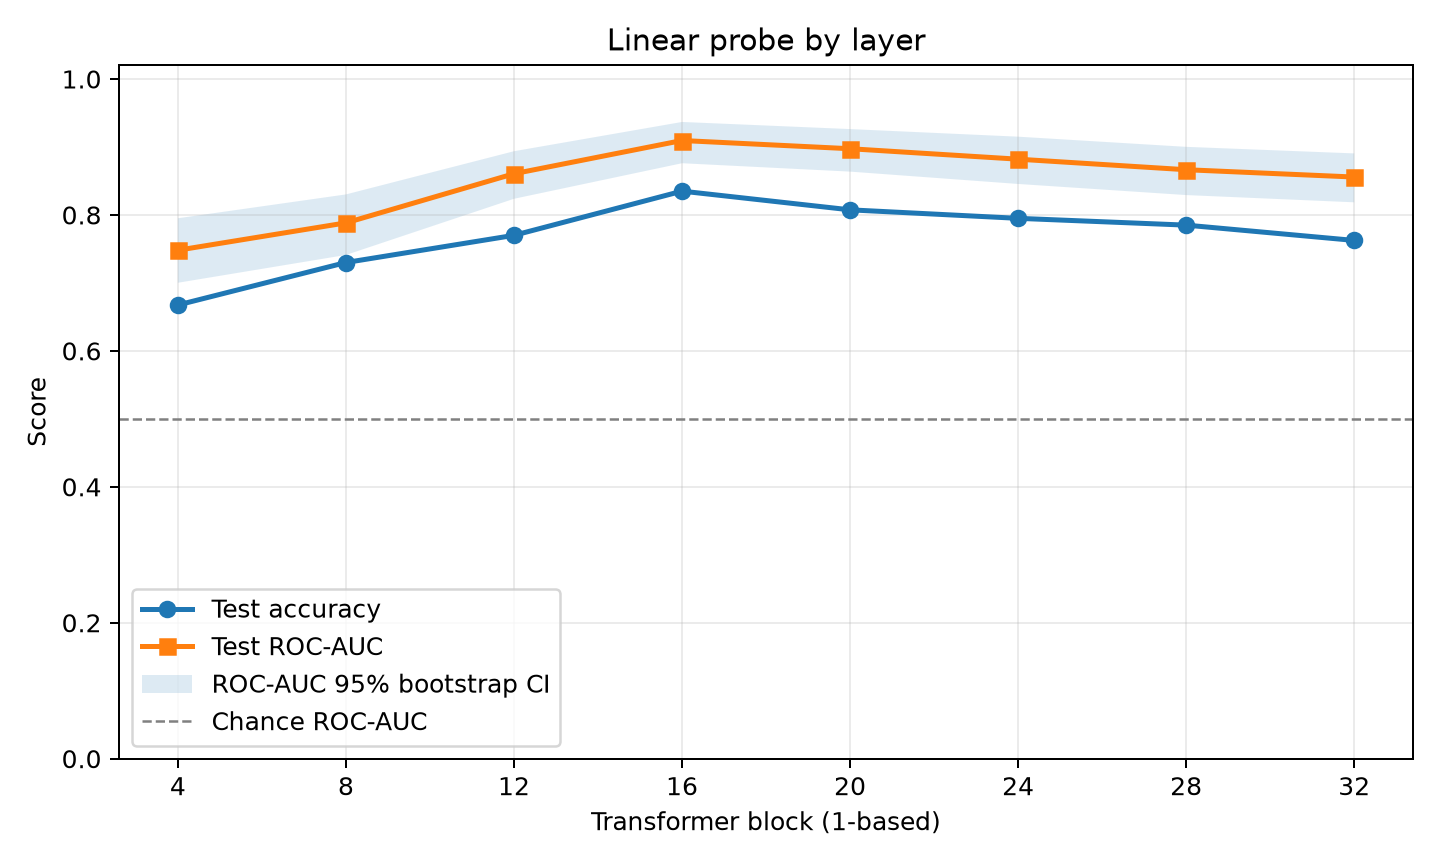

In [32]:
show_plot("qwen35_4b_probe_results_english_4bit")

**Result: English unquantized**

In [33]:
show_layer_performance("qwen35_4b_probe_results_english_unquantized")

,layer,selected_C,validation_n,validation_accuracy,validation_balanced_accuracy,validation_f1,validation_precision,validation_sensitivity,validation_specificity,validation_mcc,...,test_brier_score,test_log_loss,test_accuracy_ci_low,test_accuracy_ci_high,test_balanced_accuracy_ci_low,test_balanced_accuracy_ci_high,test_f1_ci_low,test_f1_ci_high,test_roc_auc_ci_low,test_roc_auc_ci_high
0,4,0.001,400,0.7050,0.7050,0.702020,0.709184,0.695,0.715,0.410082,...,0.203891,0.595488,0.630000,0.717500,0.629991,0.717961,0.615375,0.723750,0.700426,0.796709
1,8,0.001,400,0.7025,0.7025,0.709046,0.693780,0.725,0.680,0.405411,...,0.187855,0.554098,0.672500,0.762500,0.673016,0.762638,0.657818,0.758625,0.741066,0.828096
2,12,0.001,400,0.7500,0.7500,0.753695,0.742718,0.765,0.735,0.500225,...,0.151996,0.463609,0.740000,0.820062,0.740373,0.820663,0.740340,0.827226,0.821736,0.893684
3,16,0.001,400,0.8100,0.8100,0.817308,0.787037,0.850,0.770,0.621994,...,0.114572,0.374266,0.815000,0.885000,0.815138,0.885351,0.817252,0.886794,0.884624,0.942869
4,20,0.001,400,0.8125,0.8125,0.816626,0.799043,0.835,0.790,0.625634,...,0.121553,0.390954,0.792500,0.865000,0.792602,0.864595,0.796115,0.870603,0.875196,0.933458
5,24,0.001,400,0.8000,0.8000,0.806763,0.780374,0.835,0.765,0.601475,...,0.134494,0.426225,0.780000,0.855000,0.779857,0.855573,0.785361,0.861176,0.853909,0.921081
6,28,0.001,400,0.7800,0.7800,0.787440,0.761682,0.815,0.745,0.561377,...,0.144099,0.448550,0.762437,0.837500,0.762323,0.838354,0.765541,0.845283,0.839268,0.909122
7,32,0.001,400,0.7925,0.7925,0.799031,0.774648,0.825,0.760,0.586240,...,0.152777,0.467497,0.722438,0.802500,0.721139,0.802863,0.729458,0.814343,0.824764,0.895987


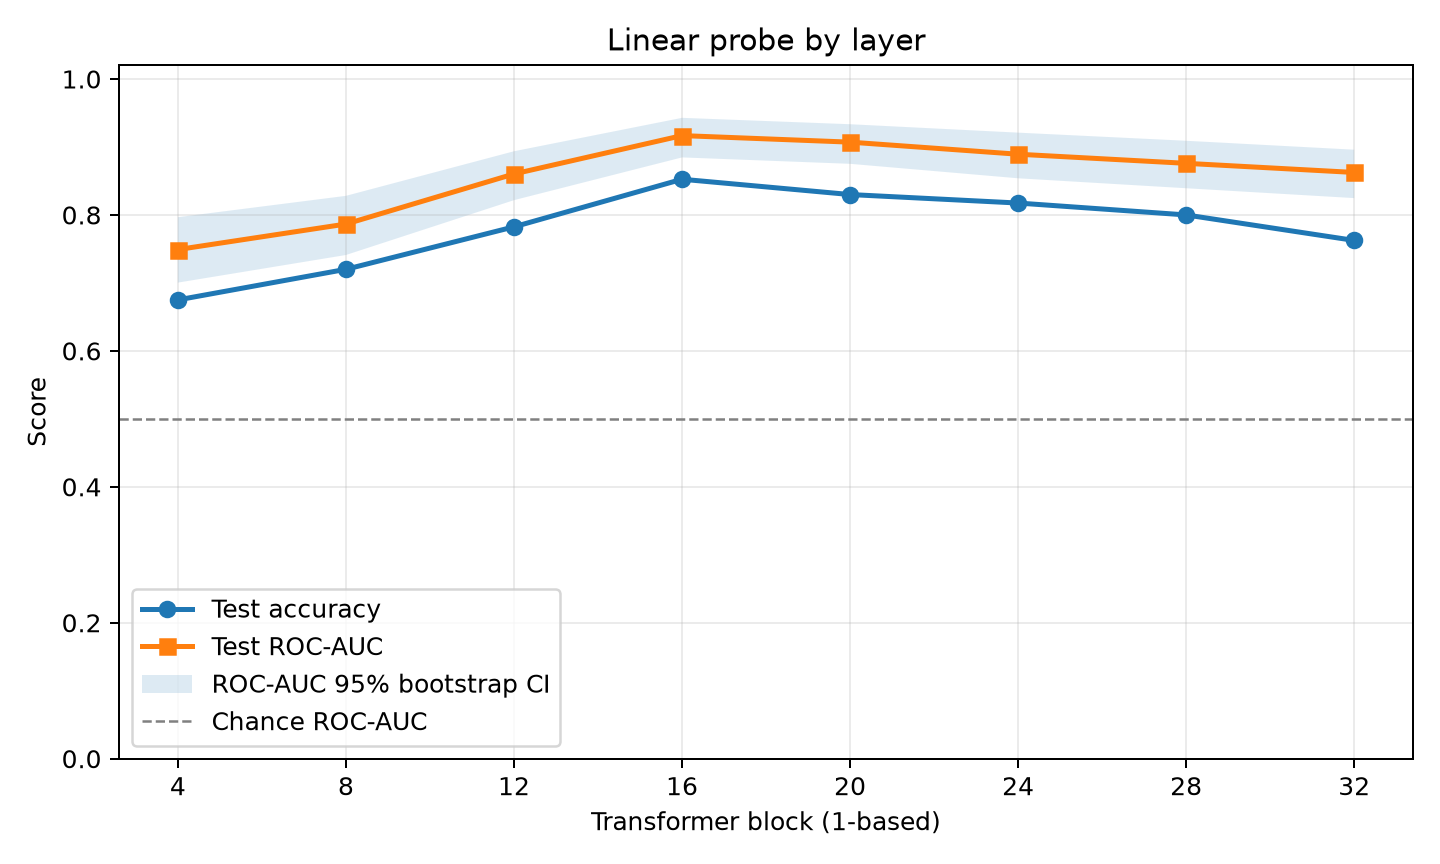

In [35]:
show_plot("qwen35_4b_probe_results_english_unquantized")